In [25]:
from pathlib import Path
import re
import pandas as pd

BASE_DIR = Path.cwd()
out_dir = BASE_DIR / "data"

print("読み込みディレクトリ:", out_dir)

files = sorted(out_dir.glob("N100_T200K_r100_omega*_alpha*_h0.001_J0.1.csv"))
print("ファイル数:", len(files))

def parse_params_from_name(path: Path):
    m = re.search(
        r"N([^_]+)_T([^_]+)_r([^_]+)_omega([-\d\.eE]+)_alpha([-\d\.eE]+)_h([-\d\.eE]+)_J([-\d\.eE]+)",
        path.stem,
    )
    if not m:
        return None
    return dict(
        N=m.group(1),
        T=m.group(2),
        r=m.group(3),
        omega=float(m.group(4)),
        alpha=float(m.group(5)),
        h=float(m.group(6)),
        J=float(m.group(7)),
        path=str(path),
    )

rows = []
for f in files:
    meta = parse_params_from_name(f)
    if not meta:
        continue
    # 1/0 を float に変換してから平均を取る
    df = pd.read_csv(f, header=None)
    v = pd.to_numeric(df.iloc[:, 1], errors="coerce")  # 数値に変換
    meta["success_prob"] = float(v.mean())             # 平均 = 成功確率
    rows.append(meta)

summary = pd.DataFrame(rows).sort_values(["omega", "alpha"])


読み込みディレクトリ: /home/mori-lab/shimizu/ACO-on-Network/src/sampling/data
ファイル数: 42


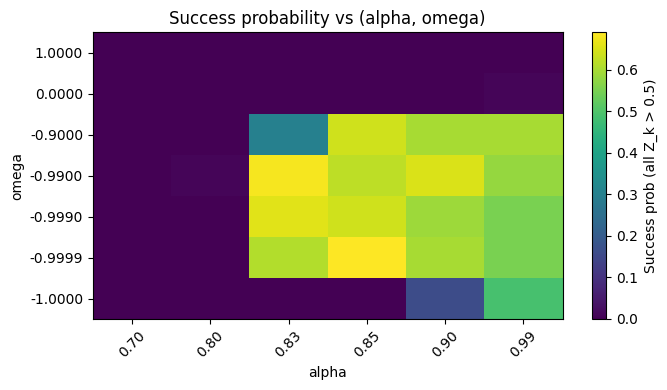

In [26]:
import matplotlib.pyplot as plt
import numpy as np

if summary.empty:
    print("summary が空です。ファイル名やパスを確認してください。")
else:
    pivot = summary.pivot(index="omega", columns="alpha", values="success_prob")

    plt.figure(figsize=(7, 4))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.xticks(
        ticks=np.arange(len(pivot.columns)),
        labels=[f"{a:.2f}" for a in pivot.columns],
        rotation=45
    )
    plt.yticks(
        ticks=np.arange(len(pivot.index)),
        labels=[f"{w:.4f}" for w in pivot.index]
    )
    plt.colorbar(label="Success prob (all Z_k > 0.5)")
    plt.xlabel("alpha")
    plt.ylabel("omega")
    plt.title("Success probability vs (alpha, omega)")
    plt.tight_layout()
    plt.show()


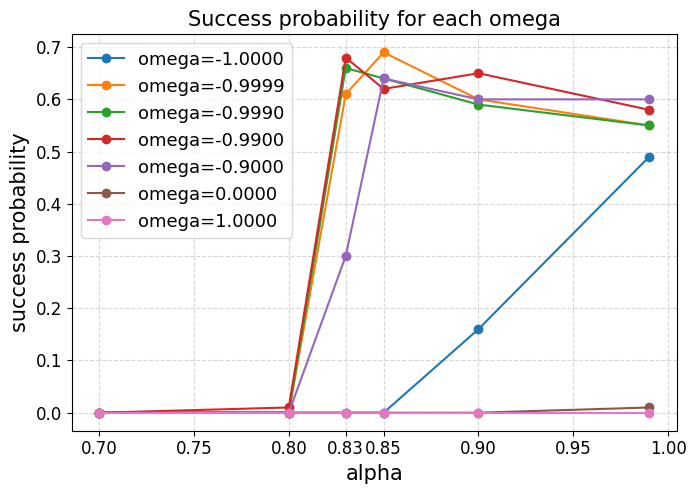

In [30]:
custom_ticks = [0.70, 0.75, 0.80, 0.83, 0.85, 0.90, 0.95, 1.00]

if summary.empty:
    print("summary が空です。ファイル名やパスを確認してください。")
else:
    plt.figure(figsize=(7, 5))
    for omega, df_omega in summary.groupby("omega"):
        df_omega = df_omega.sort_values("alpha")
        plt.plot(df_omega["alpha"], df_omega["success_prob"], marker="o", label=f"omega={omega:.4f}")
    plt.xlabel("alpha", size=15)
    plt.ylabel("success probability", size=15)
    plt.title("Success probability for each omega", size=15)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(fontsize=13)
    plt.tight_layout()
    plt.tick_params(labelsize=12)
    plt.xticks(custom_ticks)
    plt.show()
